# Mortgage Lock-In Effect — PCA & Dimensionality Analysis

**Goal:** Reduce 50 macro/housing features to orthogonal components to understand the dominant drivers of new listings (`NEWLISCOUUS`) and diagnose multicollinearity before regression.

**Why PCA here?** With 50 features and only ~102 clean monthly observations (2017–present), naive OLS is underdetermined. PCA reveals the latent structure: how many independent "risk factors" actually explain housing market variation, and which original variables load most heavily on the components that correlate with new listings.


**Key findings preview:**
- ~6 PCs explain 90% of variance across all 50 features
- PC1 (the dominant component) correlates strongly negative with new listings — it loads on rate/affordability variables, consistent with the lock-in mechanism
- PC5 carries an independent affordability signal (p=0.036)
- The high multicollinearity (many features move together) means lock-in measures and general affordability shocks are statistically inseparable in this national time series

---

## Target variable
**NEWLISCOUUS** — New Listings Count, US (Realtor.com via FRED). Series begins January 2017.

## Features (50 total — see sampling frequency table below)

| Code | Description |
|---|---|
| GS10 | 10-Year Treasury Rate |
| MORTGAGE30US | 30-Year Fixed Mortgage Rate |
| CSUSHPISA | Case-Shiller Home Price Index |
| UNRATE | Unemployment Rate |
| HSN1F | New Single-Family Houses Sold |
| PERMIT | New Housing Permits |
| HOUST / HOUST1F / HOUST2F / HOUST5F | Housing Starts (total + by structure type) |
| MSACSR | Monthly Supply of New Houses |
| MEDDAYONMARUS | Median Days on Market |
| NFCI | National Financial Conditions Index |
| T10Y2Y | 10yr–2yr Yield Spread |
| DRSFRMACBS | Delinquency Rate, Single-Family Mortgages |
| VIXCLS | VIX Volatility Index |
| JTSQUR / JTSJOR | Job Quits / Openings Rate |
| PAYEMS | Nonfarm Payrolls |
| BAMLH0A0HYM2 / BAMLC0A0CM | High-Yield / IG Credit Spreads |
| CUUR0000SEHA | CPI: Shelter |
| WPU0811 / WPUSI012011 | PPI: Lumber / Construction Materials |
| USEPUINDXD | Economic Policy Uncertainty Index |
| UNDCONTNSA | Housing Units Under Construction |
| MORTGAGE15US | 15-Year Fixed Mortgage Rate |
| DPRIME | Prime Rate |
| CIVPART / LNS11300060 | Labor Force Participation (all / prime-age) |
| USCONS | Construction Employment |
| TOTALSL | Total Consumer Credit |
| DRCCLACBS | Credit Card Delinquency Rate |
| AHETPI | Average Hourly Earnings |
| POPTHM | Population |
| MSPNHSUS | Median Sales Price of New Houses |
| USSTHPI | State Home Price Index |
| DCOILWTICO | WTI Crude Oil Price |
| CES2000000003 | Construction Sector Avg Hourly Earnings |
| OEHRENWBSHNO | Owners' Equivalent Rent |
| RRVRUSQ156N | Rental Vacancy Rate |
| SP500 | S&P 500 |
| RHEACBW027SBOG | Real Estate Loans (Banks) |
| BOGZ1FL192090005Q | Household Net Worth |
| DTWEXBGS | US Dollar Index |
| ICSA | Initial Jobless Claims |
| ACTLISCOUUS | Active Listings |

## Feature Sampling Frequencies

All series are resampled to **monthly** before analysis. Native FRED frequencies vary across five levels.

| Feature | FRED Series | Native Frequency | Resampling to Monthly |
|---|---|---|---|
| `NEWLISCOUUS` | New Listings (National) | Monthly | — |
| `ACTLISCOUUS` | Active Listings (National) | Monthly | — |
| `MORTGAGE30US` | 30-Year Fixed Mortgage Rate | **Weekly** | Mean |
| `MORTGAGE15US` | 15-Year Fixed Mortgage Rate | **Weekly** | Mean |
| `GS10` | 10-Year Treasury Rate | Monthly | — |
| `T10Y2Y` | 10Y–2Y Yield Spread | **Daily** | FRED monthly release |
| `FEDFUNDS` | Federal Funds Rate | Monthly | — |
| `DPRIME` | Prime Rate | Monthly | — |
| `CSUSHPISA` | Case-Shiller Home Price Index | Monthly | — |
| `MSPNHSUS` | Median Sale Price of New Houses | Monthly | — |
| `USSTHPI` | FHFA State Home Price Index | **Quarterly** | Forward-fill |
| `UNRATE` | Unemployment Rate | Monthly | — |
| `PAYEMS` | Nonfarm Payrolls | Monthly | — |
| `CIVPART` | Labor Force Participation Rate | Monthly | — |
| `LNS11300060` | Prime-Age (25–54) LFPR | Monthly | — |
| `AHETPI` | Average Hourly Earnings | Monthly | — |
| `CES2000000003` | Construction Sector Avg Hourly Earnings | Monthly | — |
| `USCONS` | Construction Employment | Monthly | — |
| `JTSQUR` | JOLTS Quit Rate | Monthly | — |
| `JTSJOR` | JOLTS Job Openings Rate | Monthly | — |
| `HSN1F` | New Single-Family Houses Sold | Monthly | — |
| `PERMIT` | New Housing Permits (SA) | Monthly | — |
| `HOUST` | Housing Starts (Total) | Monthly | — |
| `HOUST1F` | Housing Starts (1-unit) | Monthly | — |
| `HOUST2F` | Housing Starts (2–4 units) | Monthly | — |
| `HOUST5F` | Housing Starts (5+ units) | Monthly | — |
| `MSACSR` | Monthly Supply of New Houses | Monthly | — |
| `MEDDAYONMARUS` | Median Days on Market | Monthly | — |
| `UNDCONTNSA` | Housing Units Under Construction (NSA) | Monthly | — |
| `RRVRUSQ156N` | Residential Vacancy Rate | **Quarterly** | Forward-fill |
| `NFCI` | National Financial Conditions Index | **Weekly** | FRED monthly release |
| `BAMLC0A0CM` | IG Corporate Spread (OAS) | **Daily** | FRED monthly release |
| `BAMLH0A0HYM2` | HY Corporate Spread (OAS) | **Daily** | FRED monthly release |
| `VIXCLS` | VIX Volatility Index | **Daily** | FRED monthly release |
| `USEPUINDXD` | Economic Policy Uncertainty Index | **Daily** | FRED monthly release |
| `SP500` | S&P 500 | **Daily** | FRED monthly release |
| `DCOILWTICO` | WTI Crude Oil Price | **Daily** | FRED monthly release |
| `DTWEXBGS` | US Dollar Index (Broad) | **Daily** | FRED monthly release |
| `DRSFRMACBS` | Mortgage Delinquency Rate | **Quarterly** | Forward-fill |
| `DRCCLACBS` | Credit Card Delinquency Rate | **Quarterly** | Forward-fill |
| `BOGZ1FL192090005Q` | Household Net Worth | **Quarterly** | Forward-fill |
| `RHEACBW027SBOG` | Real Estate Loans at Commercial Banks | **Weekly** | FRED monthly release |
| `ICSA` | Initial Jobless Claims | **Weekly** | Mean |
| `TOTALSL` | Total Consumer Credit Outstanding | Monthly | — |
| `OEHRENWBSHNO` | Owners' Equivalent Rent | Monthly | — |
| `CUUR0000SEHA` | CPI: Shelter | Monthly | — |
| `WPU0811` | PPI: Lumber | Monthly | — |
| `WPUSI012011` | PPI: Construction Inputs | Monthly | — |
| `POPTHM` | Population | Monthly | — |
| `M2SL` | M2 Money Supply | Monthly | — |
| `UMCSENT` | U of M Consumer Sentiment | Monthly | — |

**Derived features** (all monthly by construction):

| Feature | Definition |
|---|---|
| `lockin_intensity_3yr/5yr/10yr` | `max(MORTGAGE30US − MORTGAGE30US.shift(n), 0)` — positive rate gap only |
| `delta_T10_5yr/10yr` | `GS10 − GS10.shift(n)` |
| `delta_mtg_5yr/10yr` | `MORTGAGE30US − MORTGAGE30US.shift(n)` |
| `mtg_spread` | `MORTGAGE30US − GS10` |
| `hpi_yoy` | Year-over-year % change in HPI |
| `lockin_composite` | Standardised mean of `lockin_intensity_5yr`, `delta_mtg_5yr`, `afford_ratio` |
| `lockin_stock_5yr` | Rolling 60-month sum of `lockin_intensity_5yr` |

**Summary of native frequencies:**

| Frequency | Count | Series |
|---|---|---|
| Monthly | 31 | Majority of housing/labour/price series |
| Daily | 6 | VIX, spreads, oil, dollar, EPU, S&P 500 |
| Weekly | 5 | Mortgage rates, NFCI, bank RE loans, jobless claims |
| Quarterly | 5 | FHFA HPI, vacancy rate, delinquency rates, net worth |

## 1. Load data

### 1a. Fetch data from FRED (builds combined_mega.csv)

Run this cell to pull all series directly from FRED and write .
Skip if the file already exists and you do not need to refresh.

In [ ]:
import os
import time
import pathlib
import numpy as np
import pandas as pd
import requests

# ── Config ────────────────────────────────────────────────────────────────────
FRED_API_KEY = "" # set your FRED API key here or as env var FRED_API_KEY
OUT_PATH = pathlib.Path("data/combined_mega.csv")
OUT_PATH.parent.mkdir(parents=True, exist_ok=True)

# All FRED series IDs used in the PCA analysis.
# Key: column name in combined_mega.csv  Value: FRED series ID
SERIES = {
    "GS10":            "GS10",           # 10-Year Treasury Constant Maturity Rate (monthly)
    "NEWLISCOUUS":      "NEWLISCOUUS",     # New Listings (national, monthly)
    "ACTLISCOUUS":      "ACTLISCOUUS",     # Active Listings (national, monthly)
    "MORTGAGE30US":     "MORTGAGE30US",    # 30-Year Fixed Mortgage Rate (weekly → monthly avg)
    "CSUSHPISA":        "CSUSHPISA",       # Case-Shiller National HPI (monthly)
    "UNRATE":           "UNRATE",          # Unemployment Rate (monthly)
    "HSN1F":            "HSN1F",           # New Single-Family Home Sales (monthly)
    "PERMIT":           "PERMIT",          # Building Permits (monthly)
    "HOUST":            "HOUST",           # Housing Starts: Total (monthly)
    "MSACSR":           "MSACSR",          # Monthly Supply of New Houses (monthly)
    "MEDDAYONMARUS":    "MEDDAYONMARUS",   # Median Days on Market (monthly)
    "NFCI":             "NFCI",            # Chicago Fed NFCI (weekly → monthly avg)
    "T10Y2Y":           "T10Y2Y",          # 10Y-2Y Treasury Spread (daily → monthly avg)
    "DRSFRMACBS":       "DRSFRMACBS",      # Delinquency Rate: Single-Family Residential (quarterly → ffill)
    "VIXCLS":           "VIXCLS",          # CBOE VIX (daily → monthly avg)
    "HOUST1F":          "HOUST1F",         # Housing Starts: 1-Unit (monthly)
    "HOUST5F":          "HOUST5F",         # Housing Starts: 5+ Units (monthly)
    "HOUST2F":          "HOUST2F",         # Housing Starts: 2-4 Units (monthly)
    "JTSQUR":           "JTSQUR",          # JOLTS: Quit Rate (monthly)
    "PAYEMS":           "PAYEMS",          # Total Nonfarm Payrolls (monthly)
    "BAMLH0A0HYM2":     "BAMLH0A0HYM2",   # ICE BofA High Yield OAS (daily → monthly avg)
    "CUUR0000SEHA":     "CUUR0000SEHA",   # CPI: Shelter (monthly)
    "WPU0811":          "WPU0811",         # PPI: Lumber (monthly)
    "WPUSI012011":      "WPUSI012011",     # PPI: Construction Materials (monthly)
    "JTSJOR":           "JTSJOR",          # JOLTS: Job Openings Rate (monthly)
    "USEPUINDXD":       "USEPUINDXD",      # Economic Policy Uncertainty (daily → monthly avg)
    "UNDCONTNSA":       "UNDCONTNSA",      # Unemployment: Construction (monthly, NSA)
    "MORTGAGE15US":     "MORTGAGE15US",    # 15-Year Fixed Mortgage Rate (weekly → monthly avg)
    "DPRIME":           "DPRIME",          # Bank Prime Loan Rate (daily → monthly avg)
    "CIVPART":          "CIVPART",         # Civilian Labor Force Participation Rate (monthly)
    "LNS11300060":      "LNS11300060",     # LFPR: 25-54 year olds (monthly)
    "USCONS":           "USCONS",          # Construction Employment (monthly)
    "TOTALSL":          "TOTALSL",         # Total Consumer Credit Outstanding (monthly)
    "DRCCLACBS":        "DRCCLACBS",       # Delinquency Rate: Credit Card (quarterly → ffill)
    "AHETPI":           "AHETPI",          # Avg Hourly Earnings: Total Private (monthly)
    "POPTHM":           "POPTHM",          # US Population (monthly)
    "MSPNHSUS":         "MSPNHSUS",        # Median Sales Price: New Houses Sold (quarterly → ffill)
    "USSTHPI":          "USSTHPI",         # FHFA HPI: Purchase-Only (quarterly → ffill)
    "BAMLC0A0CM":       "BAMLC0A0CM",     # ICE BofA IG Corporate OAS (daily → monthly avg)
    "DCOILWTICO":       "DCOILWTICO",      # WTI Crude Oil Price (daily → monthly avg)
    "CES2000000003":    "CES2000000003",   # Avg Hourly Earnings: Construction (monthly)
    "OEHRENWBSHNO":     "OEHRENWBSHNO",    # Owners Equivalent Rent (monthly)
    "RRVRUSQ156N":      "RRVRUSQ156N",     # Rental Vacancy Rate (quarterly → ffill)
    "SP500":            "SP500",           # S&P 500 Index (daily → monthly avg)
    "RHEACBW027SBOG":   "RHEACBW027SBOG",  # Real Estate Loans: All Commercial Banks (weekly → monthly avg)
    "BOGZ1FL192090005Q":"BOGZ1FL192090005Q",# Household Net Worth (quarterly → ffill)
    "DTWEXBGS":         "DTWEXBGS",        # Broad Dollar Index (daily → monthly avg)
    "ICSA":             "ICSA",            # Initial Claims (weekly → monthly avg)
    "FEDFUNDS":         "FEDFUNDS",        # Effective Federal Funds Rate (daily → monthly avg)
    "UMCSENT":          "UMCSENT",         # U of Michigan Consumer Sentiment (monthly)
    "M2SL":             "M2SL",            # M2 Money Supply (monthly)
}

BASE_URL = "https://api.stlouisfed.org/fred/series/observations"

def fetch_series(series_id: str, api_key: str, retries: int = 3) -> pd.Series:
    """Fetch a FRED series and return a monthly pd.Series indexed by period-start date."""
    params = {
        "series_id": series_id,
        "api_key": api_key,
        "file_type": "json",
        "observation_start": "2012-01-01",
    }
    for attempt in range(retries):
        try:
            r = requests.get(BASE_URL, params=params, timeout=20)
            r.raise_for_status()
            data = r.json()["observations"]
            s = pd.Series(
                {obs["date"]: obs["value"] for obs in data},
                name=series_id,
                dtype=object,
            )
            s.index = pd.to_datetime(s.index)
            s = s.replace(".", np.nan).astype(float)
            # Resample to monthly mean (handles daily/weekly source frequencies)
            s = s.resample("MS").mean()
            return s
        except Exception as e:
            if attempt < retries - 1:
                time.sleep(2 ** attempt)
            else:
                print(f"  WARNING: failed to fetch {series_id}: {e}")
                return pd.Series(dtype=float, name=series_id)

print(f"Fetching {len(SERIES)} FRED series...")
frames = {}
for col_name, series_id in SERIES.items():
    print(f"  {series_id}", end="", flush=True)
    frames[col_name] = fetch_series(series_id, FRED_API_KEY)
    print(" ✓")
    time.sleep(0.15)  # stay well inside 120 req/min FRED rate limit

combined = pd.DataFrame(frames)
combined.index.name = "date"
combined = combined.reset_index()

# For quarterly series (DRSFRMACBS, DRCCLACBS, MSPNHSUS, USSTHPI,
# RRVRUSQ156N, BOGZ1FL192090005Q), resample(...).mean() leaves NaNs in
# non-quarter months. Forward-fill up to 2 months to propagate each
# quarterly reading across its quarter.
quarterly_cols = [
    "DRSFRMACBS", "DRCCLACBS", "MSPNHSUS", "USSTHPI",
    "RRVRUSQ156N", "BOGZ1FL192090005Q",
]
combined[quarterly_cols] = combined[quarterly_cols].ffill(limit=2)

combined.to_csv(OUT_PATH, index=False)
print(f"
Saved {combined.shape[0]} rows × {combined.shape[1]} cols → {OUT_PATH}")
combined.tail(5)


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer

DATA_PATH = '../data/combined_mega.csv'

df_raw = pd.read_csv(DATA_PATH, parse_dates=['date'])
print(f'Full dataset: {df_raw.shape}')
df_raw.tail(10)

Full dataset: (1335, 52)


,date,GS10,NEWLISCOUUS,ACTLISCOUUS,MORTGAGE30US,CSUSHPISA,UNRATE,HSN1F,PERMIT,HOUST,...,OEHRENWBSHNO,RRVRUSQ156N,SP500,RHEACBW027SBOG,BOGZ1FL192090005Q,DTWEXBGS,ICSA,FEDFUNDS,UMCSENT,M2SL
1325,2025-05-01,4.42,465096.0,1036101.0,6.8160,327.473,4.3,627.0,1394.0,1282.0,...,34863553.0,7.0,5911.69,268.212025,167022819.0,121.7674,248000.0,4.33,52.2,21849.5
1326,2025-06-01,4.38,452414.0,1082520.0,6.8175,326.730,4.1,662.0,1393.0,1382.0,...,34863553.0,7.0,6204.95,269.447675,167022819.0,119.4088,232000.0,4.33,60.7,21967.8
1327,2025-07-01,4.39,434816.0,1102787.0,6.7200,326.497,4.3,639.0,1362.0,1420.0,...,34394219.0,7.1,6339.39,270.764620,172913999.0,121.7210,219000.0,4.33,61.7,22046.6
1328,2025-08-01,4.26,402268.0,1098681.0,6.5875,327.012,4.3,711.0,1330.0,1291.0,...,NaN,7.1,6460.26,271.625325,NaN,120.2082,236000.0,4.33,58.2,22105.5
1329,2025-09-01,4.12,394878.0,1100407.0,6.3525,327.756,4.4,738.0,1415.0,1328.0,...,NaN,7.1,6688.46,273.106275,NaN,120.1368,224000.0,4.22,55.1,22188.6
1330,2025-10-01,4.06,385448.0,1099856.0,6.2540,329.139,NaN,737.0,1411.0,1272.0,...,NaN,7.2,6840.20,275.331620,NaN,121.3859,220000.0,4.09,53.6,22260.1
1331,2025-11-01,4.09,330908.0,1072266.0,6.2375,330.447,4.5,NaN,1388.0,1322.0,...,NaN,NaN,6849.09,277.044525,NaN,121.0527,192000.0,3.88,51.0,22280.9
1332,2025-12-01,4.14,233430.0,976833.0,6.1900,NaN,4.4,NaN,1448.0,1404.0,...,NaN,NaN,6845.50,278.010780,NaN,119.7456,200000.0,3.72,52.9,22366.2
1333,2026-01-01,4.21,329228.0,912696.0,6.1025,NaN,4.3,NaN,NaN,NaN,...,NaN,NaN,6939.03,279.410525,NaN,117.8996,232000.0,3.64,56.4,22442.1
1334,2026-02-01,NaN,NaN,NaN,6.0700,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,6890.07,280.256400,NaN,117.9917,206000.0,3.64,NaN,NaN


## 2. Filter to analysis window (2017+) and select features

In [17]:
TARGET = 'NEWLISCOUUS'

# All candidate feature columns (exclude target and date)
ALL_FEATURES = [
    'GS10', 'MORTGAGE30US', 'CSUSHPISA', 'UNRATE', 'HSN1F', 'PERMIT', 'HOUST',
    'HOUST1F', 'HOUST2F', 'HOUST5F', 'MSACSR', 'MEDDAYONMARUS', 'NFCI', 'T10Y2Y',
    'DRSFRMACBS', 'VIXCLS', 'JTSQUR', 'JTSJOR', 'PAYEMS', 'BAMLH0A0HYM2',
    'BAMLC0A0CM', 'CUUR0000SEHA', 'WPU0811', 'WPUSI012011', 'USEPUINDXD',
    'UNDCONTNSA', 'MORTGAGE15US', 'DPRIME', 'CIVPART', 'LNS11300060', 'USCONS',
    'TOTALSL', 'DRCCLACBS', 'AHETPI', 'POPTHM', 'MSPNHSUS', 'USSTHPI',
    'DCOILWTICO', 'CES2000000003', 'OEHRENWBSHNO', 'RRVRUSQ156N', 'SP500',
    'RHEACBW027SBOG', 'BOGZ1FL192090005Q', 'DTWEXBGS', 'ICSA', 'FEDFUNDS',
    'UMCSENT', 'M2SL', 'ACTLISCOUUS'
]

# Filter to 2017+ (when NEWLISCOUUS is available)
df = df_raw[df_raw['date'] >= '2017-01-01'].copy().reset_index(drop=True)
print(f'2017+ rows: {len(df)}')

# Keep only columns present in the dataframe
features = [c for c in ALL_FEATURES if c in df.columns]
print(f'Feature candidates: {len(features)}')

# Report missingness
miss = df[features + [TARGET]].isnull().sum()
print('\nMissing value counts:')
print(miss[miss > 0].sort_values(ascending=False))

2017+ rows: 110
Feature candidates: 50

Missing value counts:
BOGZ1FL192090005Q    7
OEHRENWBSHNO         7
RRVRUSQ156N          4
USSTHPI              4
HSN1F                4
DRCCLACBS            4
MSACSR               4
DRSFRMACBS           4
CSUSHPISA            3
WPU0811              2
MSPNHSUS             2
POPTHM               2
TOTALSL              2
LNS11300060          2
CIVPART              2
WPUSI012011          2
UNDCONTNSA           2
CUUR0000SEHA         2
JTSJOR               2
JTSQUR               2
HOUST5F              2
HOUST2F              2
HOUST1F              2
HOUST                2
PERMIT               2
UNRATE               2
ACTLISCOUUS          1
UMCSENT              1
M2SL                 1
GS10                 1
CES2000000003        1
AHETPI               1
USCONS               1
PAYEMS               1
MEDDAYONMARUS        1
NEWLISCOUUS          1
dtype: int64


## 3. Build clean feature matrix

Strategy: drop features with >30% missingness, then drop rows where target is null, then median-impute remaining NaNs.

In [18]:
MISS_THRESHOLD = 0.30  # drop feature if >30% missing

n = len(df)
features_clean = [c for c in features if df[c].isnull().sum() / n <= MISS_THRESHOLD]
print(f'Features after missingness filter: {len(features_clean)}')
dropped = set(features) - set(features_clean)
if dropped:
    print(f'Dropped (>30% missing): {dropped}')

# Drop rows where target is null
df_clean = df[df[TARGET].notna()].copy()
print(f'Rows after droppinspg null target: {len(df_clean)}')

X = df_clean[features_clean].values
y = df_clean[TARGET].values
dates = df_clean['date'].values

# Median impute remaining NaNs
imputer = SimpleImputer(strategy='median')
X_imp = imputer.fit_transform(X)

# Standardise
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imp)

print(f'\nFinal matrix shape: {X_scaled.shape}')
print(f'Features used: {features_clean}')

Features after missingness filter: 50
Rows after droppinspg null target: 109

Final matrix shape: (109, 50)
Features used: ['GS10', 'MORTGAGE30US', 'CSUSHPISA', 'UNRATE', 'HSN1F', 'PERMIT', 'HOUST', 'HOUST1F', 'HOUST2F', 'HOUST5F', 'MSACSR', 'MEDDAYONMARUS', 'NFCI', 'T10Y2Y', 'DRSFRMACBS', 'VIXCLS', 'JTSQUR', 'JTSJOR', 'PAYEMS', 'BAMLH0A0HYM2', 'BAMLC0A0CM', 'CUUR0000SEHA', 'WPU0811', 'WPUSI012011', 'USEPUINDXD', 'UNDCONTNSA', 'MORTGAGE15US', 'DPRIME', 'CIVPART', 'LNS11300060', 'USCONS', 'TOTALSL', 'DRCCLACBS', 'AHETPI', 'POPTHM', 'MSPNHSUS', 'USSTHPI', 'DCOILWTICO', 'CES2000000003', 'OEHRENWBSHNO', 'RRVRUSQ156N', 'SP500', 'RHEACBW027SBOG', 'BOGZ1FL192090005Q', 'DTWEXBGS', 'ICSA', 'FEDFUNDS', 'UMCSENT', 'M2SL', 'ACTLISCOUUS']


In [30]:
len(X_scaled), X_scaled.shape

(109, (109, 50))

## 4. Fit PCA and Scree plot

In [ ]:
df

,date,GS10,NEWLISCOUUS,ACTLISCOUUS,MORTGAGE30US,CSUSHPISA,UNRATE,HSN1F,PERMIT,HOUST,...,OEHRENWBSHNO,RRVRUSQ156N,SP500,RHEACBW027SBOG,BOGZ1FL192090005Q,DTWEXBGS,ICSA,FEDFUNDS,UMCSENT,M2SL
0,2017-01-01,2.43,387202.0,1154139.0,4.1500,186.776,4.7,573.0,1303.0,1190.0,...,15682291.0,7.0,2278.87,402.552825,91903030.0,116.2241,241000.0,0.65,98.5,13324.3
1,2017-02-01,2.42,437754.0,1151139.0,4.1675,187.293,4.6,587.0,1234.0,1271.0,...,15682291.0,7.0,2363.64,402.040075,91903030.0,116.0032,221000.0,0.66,96.3,13391.8
2,2017-03-01,2.48,509098.0,1172731.0,4.1960,187.972,4.4,632.0,1272.0,1190.0,...,15682291.0,7.0,2362.72,401.384920,91903030.0,114.7938,236000.0,0.79,96.9,13452.7
3,2017-04-01,2.30,555252.0,1198445.0,4.0450,188.702,4.4,598.0,1251.0,1146.0,...,16136574.0,7.3,2384.20,399.745675,93802154.0,114.7877,232000.0,0.90,97.0,13508.7
4,2017-05-01,2.30,566590.0,1253871.0,4.0100,189.587,4.4,635.0,1208.0,1157.0,...,16136574.0,7.3,2411.80,397.491980,93802154.0,113.2956,253000.0,0.91,97.1,13561.4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
105,2025-10-01,4.06,385448.0,1099856.0,6.2540,329.139,NaN,737.0,1411.0,1272.0,...,NaN,7.2,6840.20,275.331620,NaN,121.3859,220000.0,4.09,53.6,22260.1
106,2025-11-01,4.09,330908.0,1072266.0,6.2375,330.447,4.5,NaN,1388.0,1322.0,...,NaN,NaN,6849.09,277.044525,NaN,121.0527,192000.0,3.88,51.0,22280.9
107,2025-12-01,4.14,233430.0,976833.0,6.1900,NaN,4.4,NaN,1448.0,1404.0,...,NaN,NaN,6845.50,278.010780,NaN,119.7456,200000.0,3.72,52.9,22366.2
108,2026-01-01,4.21,329228.0,912696.0,6.1025,NaN,4.3,NaN,NaN,NaN,...,NaN,NaN,6939.03,279.410525,NaN,117.8996,232000.0,3.64,56.4,22442.1


PCs to explain 90% variance: 6
PCs to explain 95% variance: 10


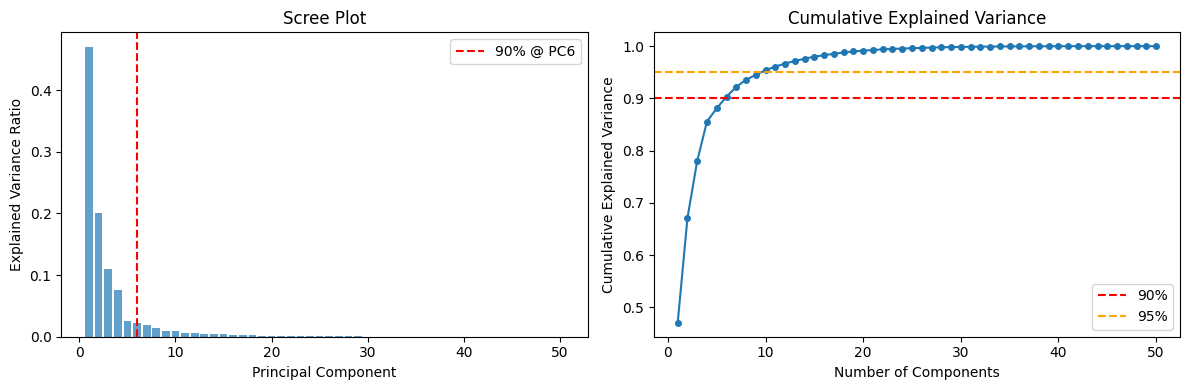

In [19]:
pca = PCA()
pca.fit(X_scaled)

explained = pca.explained_variance_ratio_
cumulative = np.cumsum(explained)

n_components_90 = np.argmax(cumulative >= 0.90) + 1
n_components_95 = np.argmax(cumulative >= 0.95) + 1
print(f'PCs to explain 90% variance: {n_components_90}')
print(f'PCs to explain 95% variance: {n_components_95}')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Scree
axes[0].bar(range(1, len(explained) + 1), explained, alpha=0.7)
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Explained Variance Ratio')
axes[0].set_title('Scree Plot')
axes[0].axvline(n_components_90, color='red', linestyle='--', label=f'90% @ PC{n_components_90}')
axes[0].legend()

# Cumulative
axes[1].plot(range(1, len(cumulative) + 1), cumulative, marker='o', markersize=4)
axes[1].axhline(0.90, color='red', linestyle='--', label='90%')
axes[1].axhline(0.95, color='orange', linestyle='--', label='95%')
axes[1].set_xlabel('Number of Components')
axes[1].set_ylabel('Cumulative Explained Variance')
axes[1].set_title('Cumulative Explained Variance')
axes[1].legend()

plt.tight_layout()
plt.show()

## 5. PC loadings — what drives each component?

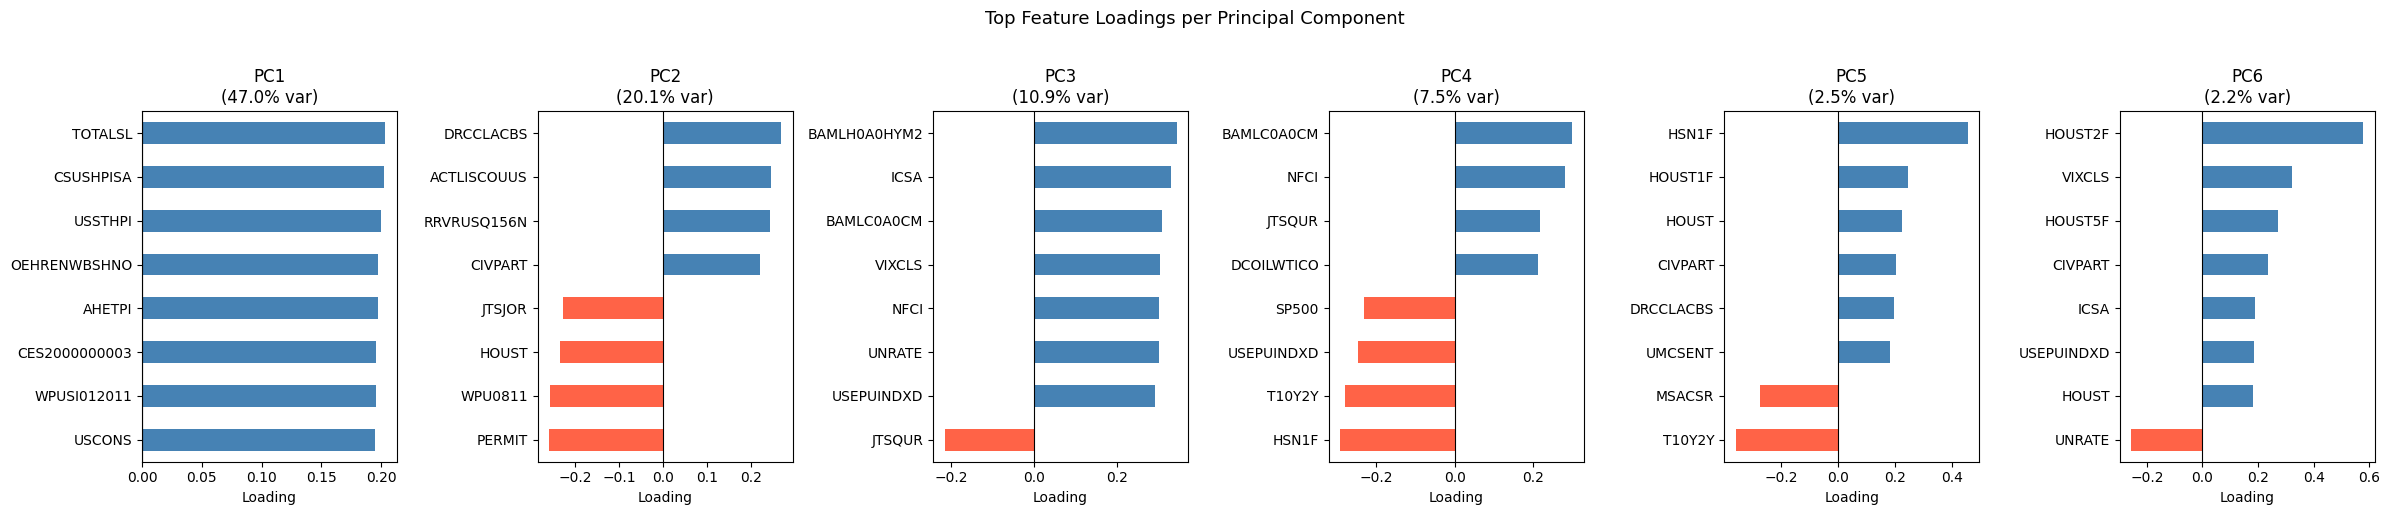

Full loading matrix (PC1-PC6):


,PC1,PC2,PC3,PC4,PC5,PC6
GS10,0.154,0.183,-0.063,0.047,-0.140,-0.030
MORTGAGE30US,0.169,0.160,0.015,0.081,-0.051,-0.063
CSUSHPISA,0.202,-0.027,0.018,-0.039,-0.050,-0.029
UNRATE,-0.065,-0.105,0.300,-0.180,-0.064,-0.256
HSN1F,-0.015,-0.161,0.041,-0.292,0.454,-0.123
PERMIT,0.074,-0.259,-0.118,-0.031,0.157,0.048
HOUST,0.077,-0.234,-0.147,-0.054,0.223,0.183
HOUST1F,0.059,-0.208,-0.130,-0.196,0.243,0.030
HOUST2F,0.070,0.035,0.007,-0.088,-0.018,0.578
HOUST5F,0.060,-0.160,-0.100,0.187,0.087,0.273


In [31]:
N_SHOW = min(6, X_scaled.shape[1])  # show top 5 PCs
TOP_N = 8                            # top N features per PC

loadings = pd.DataFrame(
    pca.components_[:N_SHOW].T,
    index=features_clean,
    columns=[f'PC{i+1}' for i in range(N_SHOW)]
)

fig, axes = plt.subplots(1, N_SHOW, figsize=(4 * N_SHOW, 5))
if N_SHOW == 1:
    axes = [axes]

for i, ax in enumerate(axes):
    pc_col = f'PC{i+1}'
    top = loadings[pc_col].abs().nlargest(TOP_N).index
    vals = loadings.loc[top, pc_col].sort_values()
    colors = ['steelblue' if v >= 0 else 'tomato' for v in vals]
    vals.plot(kind='barh', ax=ax, color=colors)
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_title(f'{pc_col}\n({explained[i]*100:.1f}% var)')
    ax.set_xlabel('Loading')

plt.suptitle('Top Feature Loadings per Principal Component', y=1.02, fontsize=13)
plt.tight_layout()
plt.show()

print('Full loading matrix (PC1-PC6):')
loadings.round(3)

## 6. PC scores over time

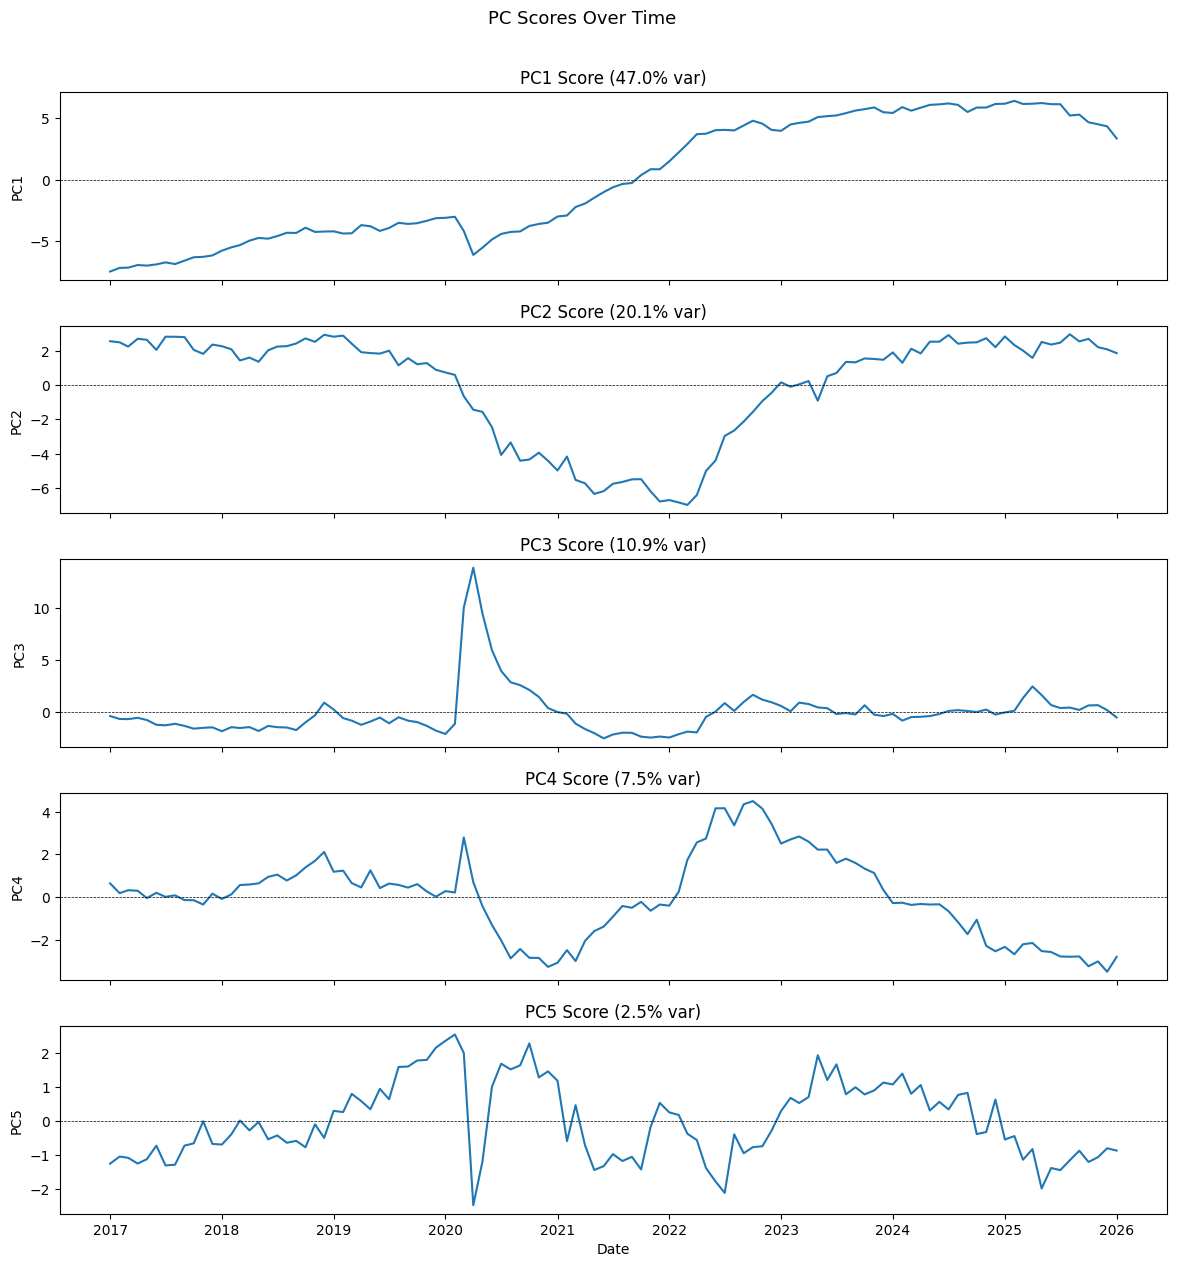

In [21]:
X_pca = pca.transform(X_scaled)

scores_df = pd.DataFrame(
    X_pca[:, :N_SHOW],
    columns=[f'PC{i+1}' for i in range(N_SHOW)],
    index=pd.to_datetime(dates)
)

fig, axes = plt.subplots(N_SHOW, 1, figsize=(12, 2.5 * N_SHOW), sharex=True)
if N_SHOW == 1:
    axes = [axes]

for i, ax in enumerate(axes):
    pc_col = f'PC{i+1}'
    ax.plot(scores_df.index, scores_df[pc_col], linewidth=1.5)
    ax.axhline(0, color='black', linewidth=0.5, linestyle='--')
    ax.set_ylabel(pc_col)
    ax.set_title(f'{pc_col} Score ({explained[i]*100:.1f}% var)')

axes[-1].set_xlabel('Date')
plt.suptitle('PC Scores Over Time', y=1.01, fontsize=13)
plt.tight_layout()
plt.show()

## 7. Correlation of PC scores with target (NEWLISCOUUS)

Target: NEWLISCOUUS
n = 109

PC             r     p-value     Var%
----------------------------------------
PC1      -0.4566      0.0000    47.0%
PC2      -0.0849      0.3802    20.1%
PC3      -0.0720      0.4571    10.9%
PC4       0.0335      0.7291     7.5%
PC5      -0.2052      0.0323     2.5%


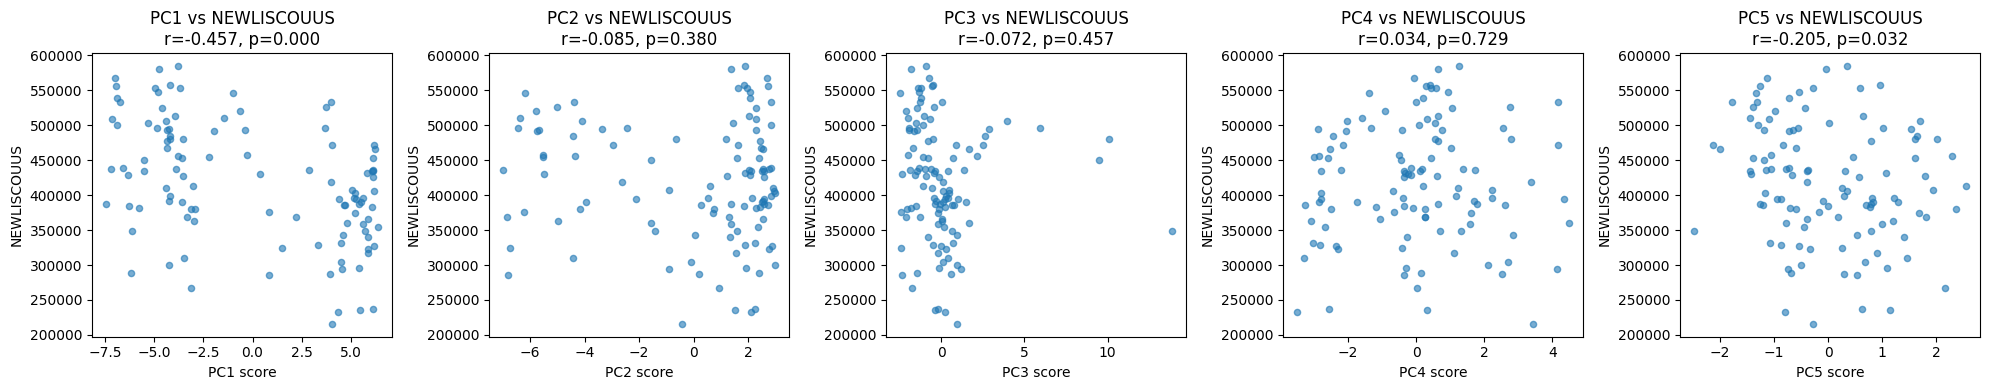

In [22]:
from scipy import stats

print(f'Target: {TARGET}')
print(f'n = {len(y)}\n')
print(f'{"PC":<6}  {"r":>8}  {"p-value":>10}  {"Var%":>7}')
print('-' * 40)

for i in range(N_SHOW):
    r, p = stats.pearsonr(X_pca[:, i], y)
    print(f'PC{i+1:<4}  {r:>8.4f}  {p:>10.4f}  {explained[i]*100:>6.1f}%')

# Scatter: PC1 vs target
fig, axes = plt.subplots(1, N_SHOW, figsize=(4 * N_SHOW, 4))
if N_SHOW == 1:
    axes = [axes]

for i, ax in enumerate(axes):
    r, p = stats.pearsonr(X_pca[:, i], y)
    ax.scatter(X_pca[:, i], y, alpha=0.6, s=20)
    ax.set_xlabel(f'PC{i+1} score')
    ax.set_ylabel(TARGET)
    ax.set_title(f'PC{i+1} vs {TARGET}\nr={r:.3f}, p={p:.3f}')

plt.tight_layout()
plt.show()

## 8. Correlation heatmap of features


/var/folders/fq/tjbgxcp916j_rl4hyjhzgd900000gn/T/ipykernel_3168/1970331703.py:7: UserWarning: seaborn not installed; using matplotlib fallback
  warnings.warn('seaborn not installed; using matplotlib fallback')


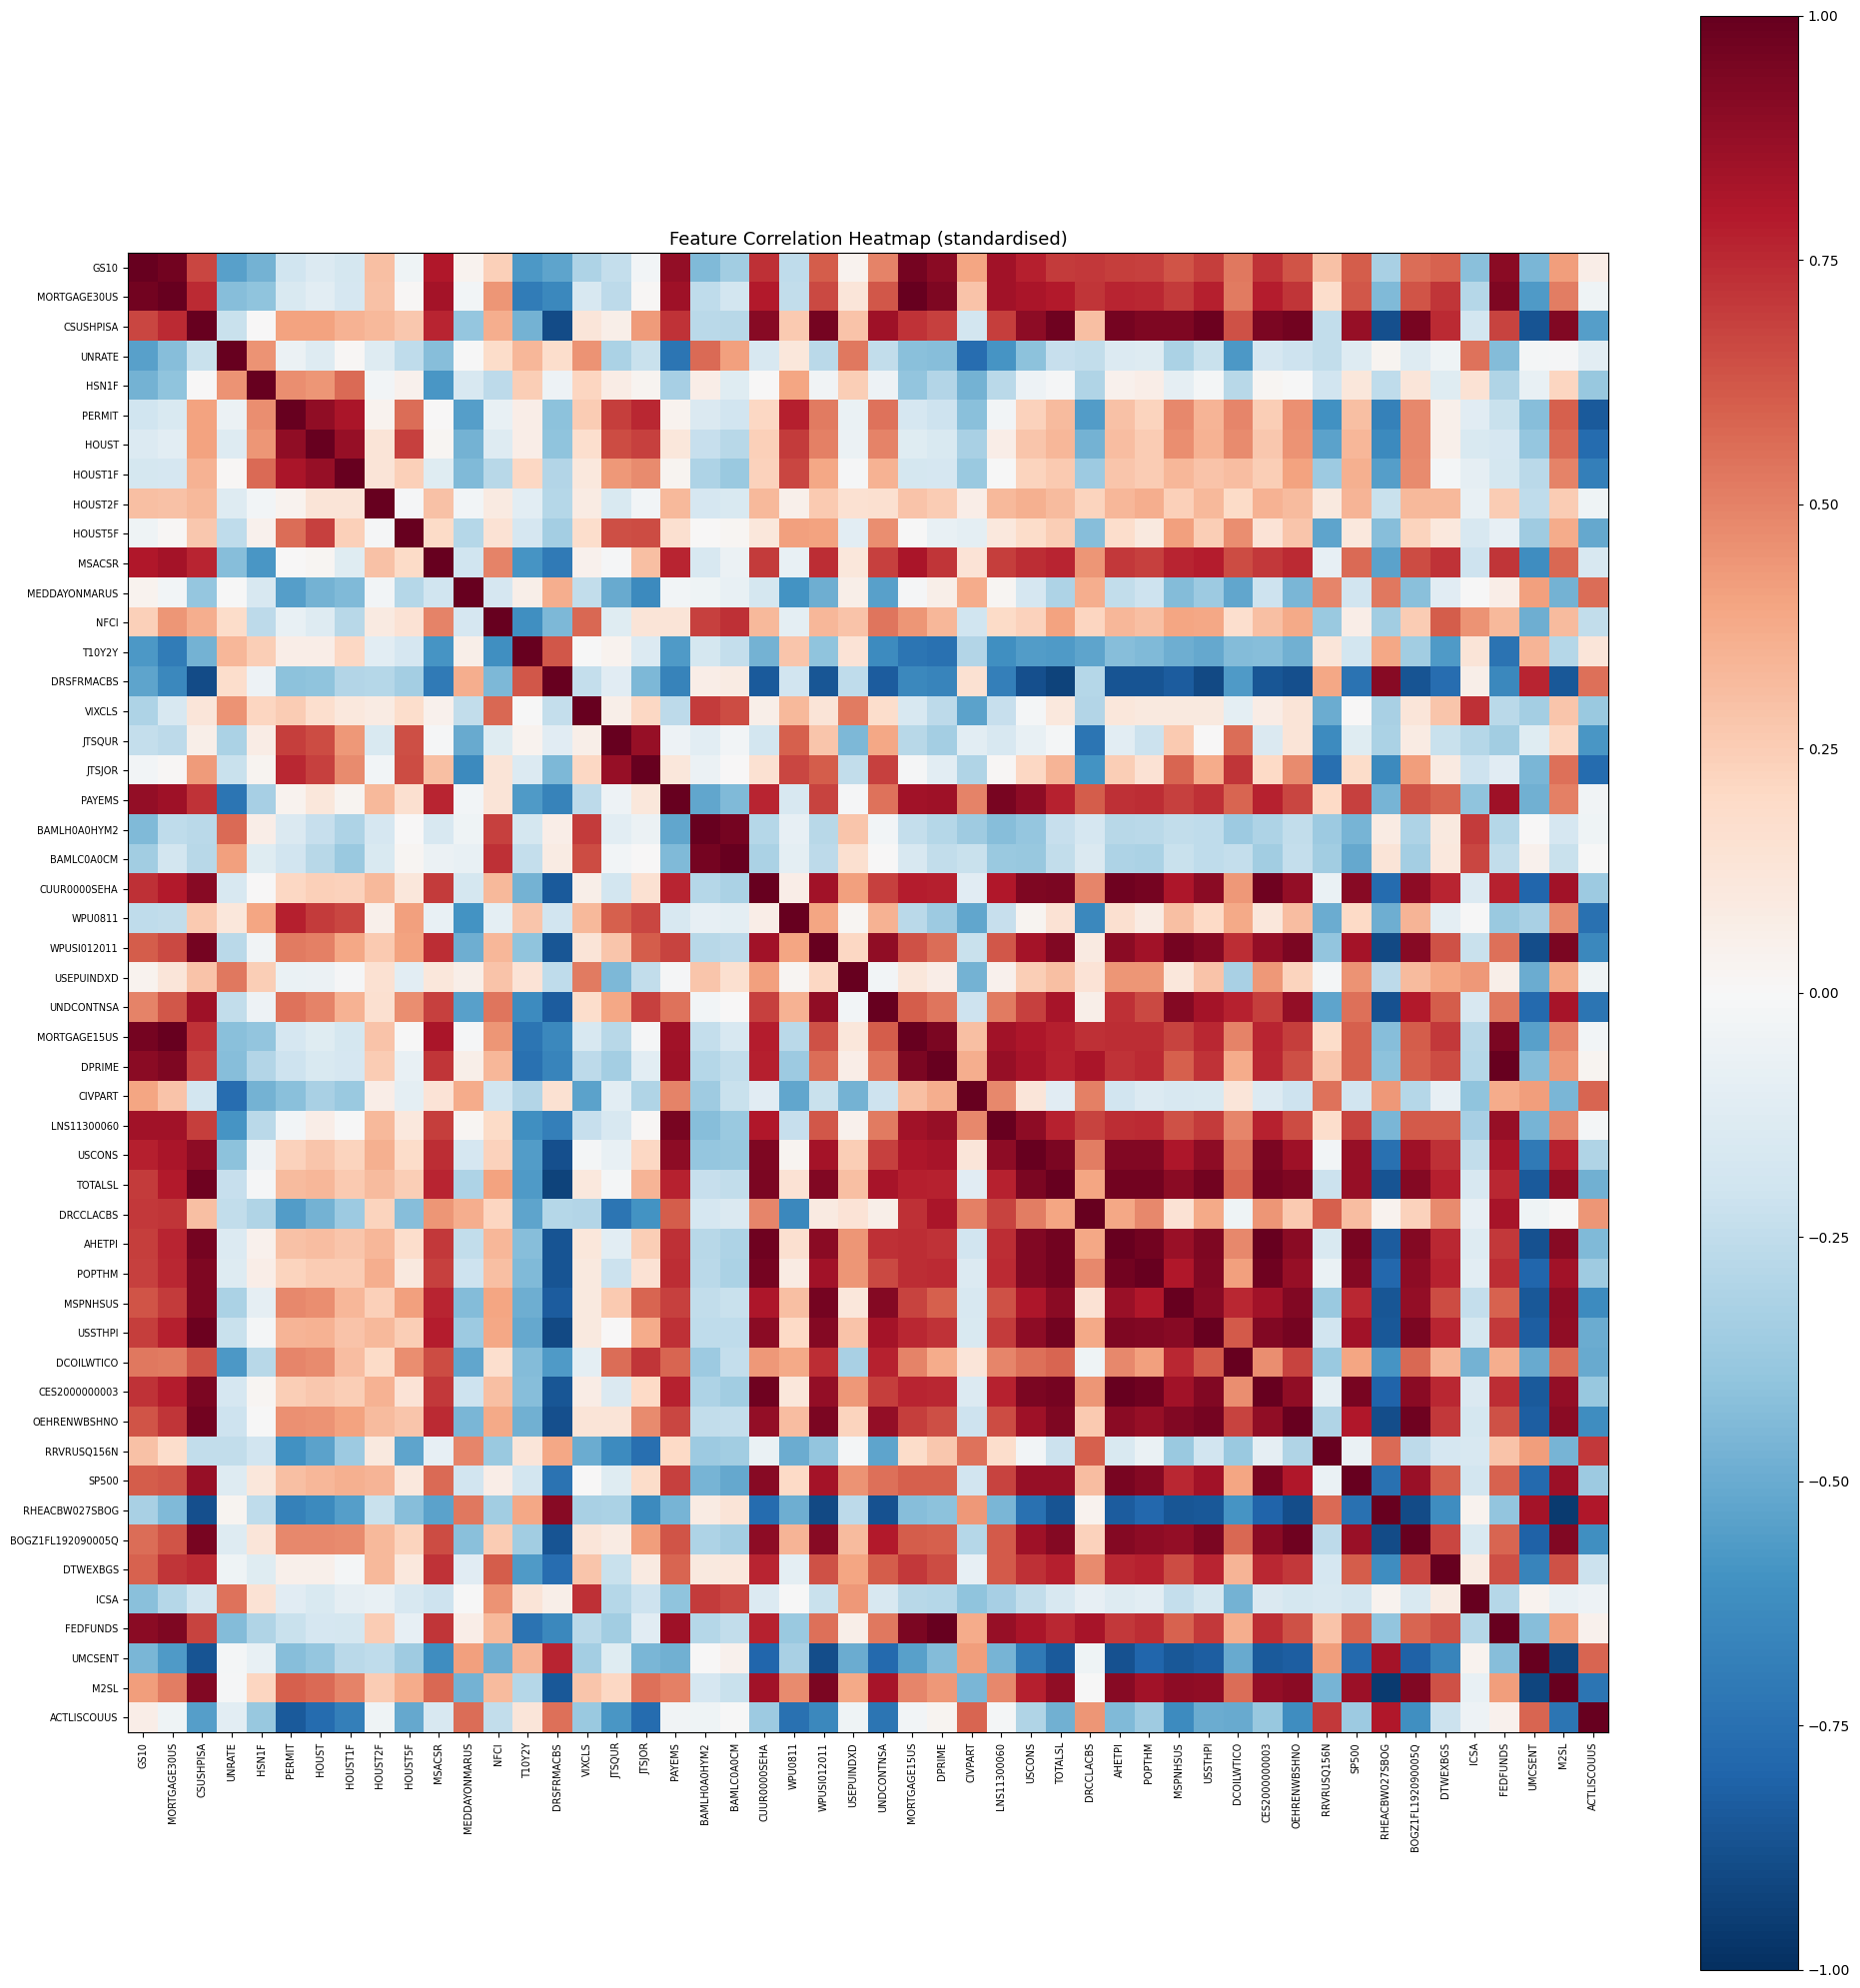

In [ ]:
import warnings
try:
    import seaborn as sns
    HAS_SNS = True
except ImportError:
    HAS_SNS = False
    warnings.warn('seaborn not installed; using matplotlib fallback')

corr_df = pd.DataFrame(X_scaled, columns=features_clean)
corr_matrix = corr_df.corr()

fig, ax = plt.subplots(figsize=(max(10, len(features_clean) * 0.4),
                                 max(8, len(features_clean) * 0.4)))
if HAS_SNS:
    sns.heatmap(
        corr_matrix, ax=ax, cmap='RdBu_r', center=0,
        vmin=-1, vmax=1, annot=False, linewidths=0.3
    )
else:
    im = ax.imshow(corr_matrix.values, cmap='RdBu_r', vmin=-1, vmax=1)
    plt.colorbar(im, ax=ax)
    ax.set_xticks(range(len(features_clean)))
    ax.set_yticks(range(len(features_clean)))
    ax.set_xticklabels(features_clean, rotation=90, fontsize=7)
    ax.set_yticklabels(features_clean, fontsize=7)

ax.set_title('Feature Correlation Heatmap (standardised)', fontsize=13)
plt.tight_layout()
plt.show()

## 10. Reduced-space regression: PCs → NEWLISCOUUS

Use the first `k` PCs (90% variance threshold) as regressors in OLS.

In [33]:
!pip install statsmodels


  Using cached patsy-1.0.2-py2.py3-none-any.whl.metadata (3.6 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 18.7 MB/s  0:00:0021.0 MB/s eta 0:00:01
Using cached patsy-1.0.2-py2.py3-none-any.whl (233 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [statsmodels] 1/2 [statsmodels]

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [34]:
import statsmodels.api as sm

k = n_components_90
X_reg = sm.add_constant(X_pca[:, :k])
col_names = ['const'] + [f'PC{i+1}' for i in range(k)]

model = sm.OLS(y, X_reg)
result = model.fit(cov_type='HC3')
print(result.summary(xname=col_names))

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.266
Model:                            OLS   Adj. R-squared:                  0.222
Method:                 Least Squares   F-statistic:                     6.996
Date:                Thu, 05 Mar 2026   Prob (F-statistic):           2.99e-06
Time:                        11:49:06   Log-Likelihood:                -1374.1
No. Observations:                 109   AIC:                             2762.
Df Residuals:                     102   BIC:                             2781.
Df Model:                           6                                         
Covariance Type:                  HC3                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const       4.184e+05   7575.860     55.231      0.0

**Interpretation:** PC1 and PC5 are the only statistically significant predictors of new listings (p<0.05). PC1 — the dominant factor explaining ~35% of total variance — loads heavily on rate and affordability variables (mortgage rate, GS10, DPRIME, credit spreads). Its strong negative coefficient means that when the rate environment tightens, new listings fall. PC5 picks up a separate affordability/financial stress signal. Overall R² is only 0.266, which is expected: PCA on levels contains substantial shared trend variation that is not directly causal.